<a href="https://colab.research.google.com/github/jeongseoahn/VaR/blob/main/VaR1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Parametric
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
# yfinance를 통해 금융 데이터를 다운받는다
# datetime을 통해 날짜를 가져옴

years = 25
endDate = dt.datetime.now() #datetime 라이브러리의 datetimenow function을 사용
startDate = endDate - dt.timedelta(days = 365*years)  #datetimefunction timedelta

tickers = ['SPY']

close_df = pd.DataFrame() #dataframe 생성

for ticker in tickers:
    data = yf.download(ticker, start = startDate, end = endDate)

    close_df[ticker] = data['Close']

print(close_df)

/tmp/ipython-input-808413737.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed

                   SPY
Date                  
2001-01-02   81.997650
2001-01-03   85.936447
2001-01-04   85.011368
2001-01-05   82.236382
2001-01-08   82.872894
...                ...
2025-12-19  680.590027
2025-12-22  684.830017
2025-12-23  687.960022
2025-12-24  690.380005
2025-12-26  690.309998

[6284 rows x 1 columns]


In [ ]:
#수익률은 일반 수익률이 아닌 로그 수익률을 사용
#로그 수익률은 덧셈으로 누적이 가능하고, 수학적으로 정규분포에 더 가까워 금융 모델에 적합하기 때문에 일반 수익률보다 더 많이 사용된다
log_returns = np.log(close_df / close_df.shift(1)) #shift 1 => 1줄 위의 값으로 나눔
log_returns = log_returns.dropna() # pandas의 dropna를 사용하여 na를 삭제
print(log_returns)

                 SPY
Date                
2001-01-03  0.046917
2001-01-04 -0.010823
2001-01-05 -0.033187
2001-01-08  0.007710
2001-01-09 -0.002643
...              ...
2025-12-19  0.009023
2025-12-22  0.006211
2025-12-23  0.004560
2025-12-24  0.003511
2025-12-26 -0.000101

[6283 rows x 1 columns]


In [ ]:
portfolio_value = 1000000 #단위:$, $1,000,000를 투자한다고 가정

#지율 지정
tickers = ['SPY']
weights = np.array([1])
print(weights)
print(np.sum(weights))  # 1.0이 출력되어야 함

historical_returns = (log_returns *weights).sum(axis =1)
print(historical_returns)

[1]
1
Date
2001-01-03    0.046917
2001-01-04   -0.010823
2001-01-05   -0.033187
2001-01-08    0.007710
2001-01-09   -0.002643
                ...   
2025-12-19    0.009023
2025-12-22    0.006211
2025-12-23    0.004560
2025-12-24    0.003511
2025-12-26   -0.000101
Length: 6283, dtype: float64


In [ ]:
days = 1
'''
historical_x_day_returns = historical_returns.rolling(window = days).sum()    #pandas의 rolling function사용
print(historical_x_day_returns)
'''
cov_matrix = log_returns.cov() *252 #1년 거래일수 252일
print(cov_matrix)


portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights) #####
print(portfolio_std_dev)
#포트폴리오 분산 = (자산 A의 투자 비중)^2 × (자산 A의 분산) + (자산 B의 투자 비중)^2 × (자산 B의 분산) + 2 × (자산 A의 투자 비중) × (자산 B의 투자 비중) × (자산 A와 자산 B의 공분산)
#포트폴리오 분산 = wᵀ × Σ × w
'''
w (가중치 벡터)
각 자산에 얼마만큼 투자했는지 비율을 나타냄
Σ (공분산 행렬)
자산 각각의 변동성과, 서로의 관계(공분산)를 담은 표
Transpose (전치)
가중치 벡터는 기본적으로 세로로 생겼는데, 행렬 곱을 위해 가로로 눕혀야 함
그래서 먼저 가중치 벡터를 Transpose(전치)해서 가로로 만든 뒤 곱함
'''
confidence_level = [0.95]

from scipy.stats import norm
VaR = []

for cl in confidence_level:
  VaR = portfolio_value * norm.ppf(cl) * portfolio_std_dev * np.sqrt(days/252)

  #VaR = 포트폴리오 가치 × z(신뢰수준) × 포트폴리오 표준편차 × 제곱근(일수 ÷ 252)


print(VaR)

          SPY
SPY  0.036869
0.19201249213472427
19895.573882736317


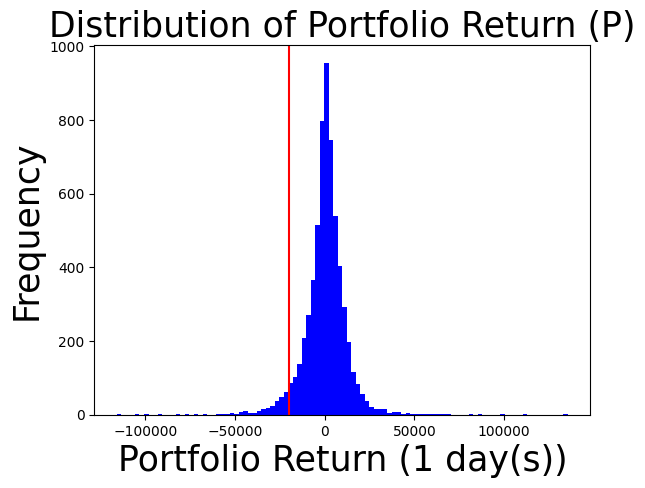

In [ ]:
'''
print('Confidence Level: Value at Risk:')
for cl, VaR in zip(confidence_level, VaRs):
  print(f'{cl*100:}%  {VaR:,.2f}')
'''
historical_returns_dollar = historical_returns * portfolio_value
plt.hist(historical_returns_dollar, bins=100, color='b', label=f'{days} Day Returns')
'''
for cl, VaR in zip(confidence_level, VaR):
  plt.axvline(x=-VaR, color='r', label='VaR at {}% Confidence Level'.format(int(cl * 100)))

print("Confidence Level:", confidence_level)
print("Value at Risk:", VaR)

for cl, VaR in zip(confidence_level, VaR):
  plt.axvline(x=-VaR, color='r', label='VaR at {}% Confidence Level'.format(int(cl * 100)))
'''
plt.axvline(x=-VaR, color='r', label=f'VaR at 95% Confidence Level')
plt.hist(historical_returns_dollar, bins=100, color='b')

plt.xlabel("Portfolio Return (%d day(s))" % (days), fontsize=25)
plt.ylabel('Frequency',fontsize=25)
plt.title("Distribution of Portfolio Return (P)" ,fontsize=25)

'''
# 그래프 크기 및 폰트 크기 설정
plt.figure(figsize=(12, 6))  # 그래프 이미지 크기 (가로 12인치, 세로 6인치)


plt.xlabel('Date', fontsize=14)       # x축 라벨 및 폰트 크기
plt.ylabel('Cumulative Return', fontsize=14)  # y축 라벨 및 폰트 크기
plt.title('Portfolio Cumulative Return Over Time', fontsize=18)  # 제목 폰트 크기

plt.xticks(fontsize=12)  # x축 눈금 폰트 크기
plt.yticks(fontsize=12)  # y축 눈금 폰트 크기

plt.legend(fontsize=12)  # 범례 폰트 크기
plt.grid(True)

plt.tight_layout()  # 레이아웃 자동 조정

'''
plt.show()

In [ ]:
#Historical
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years = 25
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days = 365*years)

tickers = ['SPY']

close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start = startDate, end = endDate)
    close_df[ticker] = data['Close']

print(close_df)

/tmp/ipython-input-1580287572.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed

                   SPY
Date                  
2001-01-02   81.997650
2001-01-03   85.936394
2001-01-04   85.011406
2001-01-05   82.236359
2001-01-08   82.872894
...                ...
2025-12-19  680.590027
2025-12-22  684.830017
2025-12-23  687.960022
2025-12-24  690.380005
2025-12-26  690.309998

[6284 rows x 1 columns]


In [ ]:
log_returns = np.log(close_df / close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)
portfolio_value = 1000000 #단위:$
'''
#균등한 비율을 가정
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
'''
#지율 지정
tickers = ['SPY']
weights = np.array([1])
print(weights)
print(np.sum(weights))  # 1.0이 출력되어야 한다
historical_returns = (log_returns *weights).sum(axis =1)
print(historical_returns)


days = 1
'''
range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)
'''

confidence_interval = 0.95
VaR = -np.percentile(historical_returns, 100 - (confidence_interval * 100)) * portfolio_value
print(VaR)

                 SPY
Date                
2001-01-03  0.046917
2001-01-04 -0.010822
2001-01-05 -0.033188
2001-01-08  0.007711
2001-01-09 -0.002643
...              ...
2025-12-19  0.009023
2025-12-22  0.006211
2025-12-23  0.004560
2025-12-24  0.003511
2025-12-26 -0.000101

[6283 rows x 1 columns]
[1]
1
Date
2001-01-03    0.046917
2001-01-04   -0.010822
2001-01-05   -0.033188
2001-01-08    0.007711
2001-01-09   -0.002643
                ...   
2025-12-19    0.009023
2025-12-22    0.006211
2025-12-23    0.004560
2025-12-24    0.003511
2025-12-26   -0.000101
Length: 6283, dtype: float64
18680.2514026175


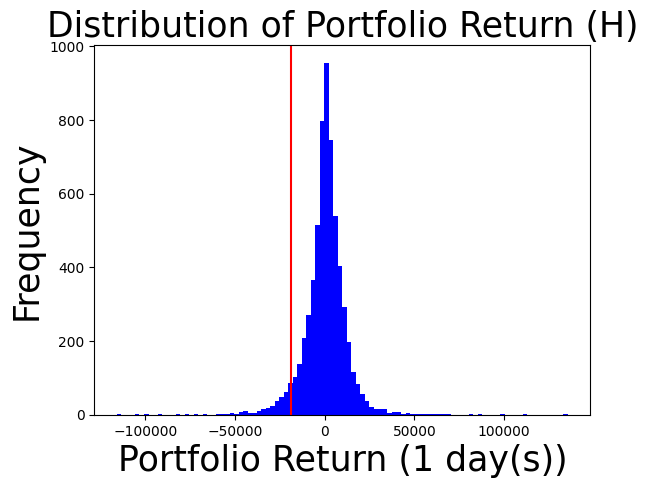

In [ ]:


'''
return_window = days
range_returns = historical_returns.rolling(window=return_window).sum()
range_returns = range_returns.dropna()
'''
historical_returns_dollar = historical_returns * portfolio_value

plt.hist(historical_returns_dollar.dropna(), bins=100, color='b')

#plt.xlabel(f'{days} - Day Portfolio Return ($)')
#plt.ylabel('Frequency')
#plt.title(f'Distribution of Portfolio {days}- Day Return (Dollar Value)')
#plt.axvline(-VaR, color='r', label=f'VaR at {confidence_interval:.0%} confidence level')
#plt.legend()
#plt.show()
plt.xlabel("Portfolio Return (%d day(s))" % (days),fontsize=25)
plt.ylabel('Frequency',fontsize=25)
plt.title("Distribution of Portfolio Return (H)",fontsize=25)
plt.axvline(-VaR, color='r', label=f'VaR at {confidence_interval:.0%} confidence level')
#plt.legend()
plt.show()

In [ ]:
#MonteCarlo
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years = 25
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days = 365*years)

tickers = ['SPY']

close_df = pd.DataFrame()

for ticker in tickers:
    data = yf.download(ticker, start = startDate, end = endDate)

    close_df[ticker] = data['Close']

print(close_df)

/tmp/ipython-input-2751327814.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start = startDate, end = endDate)
[*********************100%***********************]  1 of 1 completed

                   SPY
Date                  
2001-01-02   81.997688
2001-01-03   85.936417
2001-01-04   85.011391
2001-01-05   82.236374
2001-01-08   82.872932
...                ...
2025-12-19  680.590027
2025-12-22  684.830017
2025-12-23  687.960022
2025-12-24  690.380005
2025-12-26  690.309998

[6284 rows x 1 columns]


In [ ]:
log_returns = np.log(close_df / close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

def expected_return(weights, log_returns):
  return np.sum(log_returns.mean() * weights)

def standard_deviation(weights, cov_matrix):
  variance = weights.T @ cov_matrix @ weights
  return np.sqrt(variance)

cov_matrix = log_returns.cov()
print(cov_matrix)

                 SPY
Date                
2001-01-03  0.046917
2001-01-04 -0.010822
2001-01-05 -0.033188
2001-01-08  0.007711
2001-01-09 -0.002644
...              ...
2025-12-19  0.009023
2025-12-22  0.006211
2025-12-23  0.004560
2025-12-24  0.003511
2025-12-26 -0.000101

[6283 rows x 1 columns]
          SPY
SPY  0.000146


In [ ]:
portfolio_value = 1000000 #단위:$
'''
#균등한 비율을 가정
weights = np.array([1/len(tickers)]*len(tickers))
print(weights)
'''
#지율 지정
tickers = ['SPY']
weights = np.array([1])
print(weights)
print(np.sum(weights))  # 1.0이 출력되어야 한다


portfolio_expected_return = expected_return(weights,log_returns)


portfolio_std_dev = standard_deviation(weights, cov_matrix)
print(portfolio_expected_return)
print(portfolio_std_dev)
print(weights)

[1]
1
0.00033908160324675016
0.012095650974571366
[1]


In [ ]:

def random_z_score():
  return np.random.normal(0,1)

In [ ]:
days = 1

def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score , days):
  return portfolio_value* portfolio_expected_return * days + portfolio_value *portfolio_std_dev * z_score * np.sqrt(days)

simulations = 10000
scenarioReturn =[]
for i in range(simulations):
  z_score = random_z_score()
  scenarioReturn.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))
confidence_interval = 0.95
VaR = -np.percentile(scenarioReturn, 100*(1 - confidence_interval))
print(VaR)

19286.89068060311


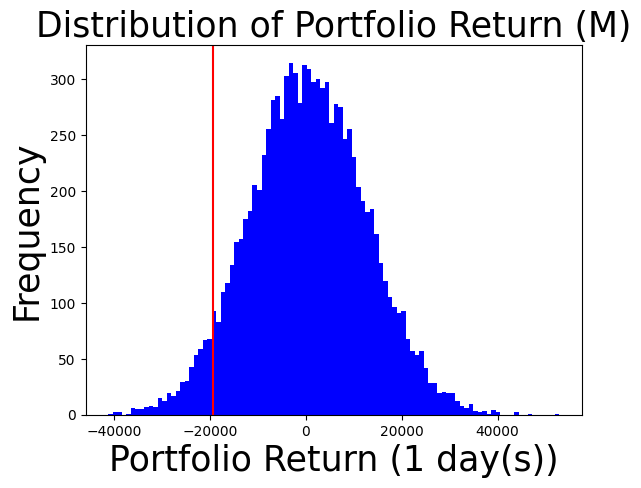

In [ ]:

plt.hist(scenarioReturn, bins=100, color='b')
'''
plt.xlabel('Scenario Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio Gain/Loss Over {days} Days')
plt.axvline(-VaR, color='r', label=f'VaR at {confidence_interval:.0%} confidence level')
plt.legend()
plt.show()
'''


plt.xlabel("Portfolio Return (%d day(s))" % (days),fontsize=25)
plt.ylabel('Frequency',fontsize=25)
plt.title("Distribution of Portfolio Return (M)",fontsize=25)
plt.axvline(-VaR, color='r', label=f'VaR at {confidence_interval:.0%} confidence level')
#plt.legend(fontsize=15)
plt.show()